# ML Regression from Scratch - Notebook 7: Comprehensive Evaluation Metrics

**Goal:** go deep on evaluating the logistic regression model from
`logistic_regression_single_feature_totalhours.ipynb` - single feature
(`TotalHours`), pass mark `CapstoneScore >= 50`. This notebook covers the
metrics that a single accuracy number hides: a confusion-matrix
deep-dive, threshold tuning at 0.3/0.5/0.7, the precision-recall
trade-off, ROC/AUC, the precision-recall curve, and a business-impact
discussion of which threshold to actually use - all implemented from
scratch with NumPy.

We will:
1. Rebuild the exact model from the single-feature notebook (same split,
   same training)
2. Confusion matrix deep-dive - what each cell means for this problem
3. Threshold tuning at 0.3, 0.5, 0.7
4. Precision-recall trade-off analysis
5. ROC curve & AUC, from scratch
6. Precision-Recall curve, from scratch
7. Business impact discussion - which threshold to actually deploy

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Rebuild the model

Identical setup to the single-feature notebook: `TotalHours` as the only
feature, pass mark 50, stratified 80/20 split, standardized feature,
logistic regression trained from scratch.

In [10]:
df = pd.read_csv('student scores.csv')
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)

PASS_MARK = 50
df['Pass'] = (df['CapstoneScore'] >= PASS_MARK).astype(int)
print(f"Pass rate at cut-off {PASS_MARK}: {df['Pass'].mean():.1%}")


def stratified_train_test_split(X, y, test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    y = np.asarray(y)
    train_idx_parts, test_idx_parts = [], []
    for class_value in np.unique(y):
        class_idx = np.where(y == class_value)[0]
        shuffled = rng.permutation(class_idx)
        n_test = max(1, int(len(shuffled) * test_size))
        test_idx_parts.append(shuffled[:n_test])
        train_idx_parts.append(shuffled[n_test:])
    train_idx = rng.permutation(np.concatenate(train_idx_parts))
    test_idx = rng.permutation(np.concatenate(test_idx_parts))
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def standardize_features(X, mu=None, sigma=None):
    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])


def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def compute_logistic_cost(X_design, y, theta, eps=1e-15):
    m = len(y)
    h = sigmoid(X_design.dot(theta))
    h = np.clip(h, eps, 1 - eps)
    return -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))


def compute_logistic_gradients(X_design, y, theta):
    m = len(y)
    h = sigmoid(X_design.dot(theta))
    return (1 / m) * X_design.T.dot(h - y)


def logistic_gradient_descent(X_design, y, learning_rate, n_iterations=3000, theta_init=None):
    n = X_design.shape[1]
    theta = np.zeros(n) if theta_init is None else theta_init
    cost_history = []
    for i in range(n_iterations):
        cost = compute_logistic_cost(X_design, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        theta = theta - learning_rate * compute_logistic_gradients(X_design, y, theta)
    return theta, cost_history


def predict_proba(X_design, theta):
    return sigmoid(X_design.dot(theta))


def predict_class(X_design, theta, threshold=0.5):
    return (predict_proba(X_design, theta) >= threshold).astype(int)


X = df[['TotalHours']].values.astype(float)
y = df['Pass'].values.astype(float)

X_train, X_test, y_train, y_test = stratified_train_test_split(X, y, test_size=0.2, seed=42)
X_train_scaled, mu, sigma = standardize_features(X_train)
X_test_scaled, _, _ = standardize_features(X_test, mu, sigma)
X_train_design = add_bias(X_train_scaled)
X_test_design = add_bias(X_test_scaled)

theta, cost_history = logistic_gradient_descent(X_train_design, y_train, learning_rate=0.5, n_iterations=3000)

print(f"Trained for {len(cost_history)} iterations, final cost = {cost_history[-1]:.4f}")
print(f"theta = {theta.round(4)}")
print(f"Test set: {len(y_test)} rows, pass rate {y_test.mean():.1%}")

Pass rate at cut-off 50: 58.3%
Trained for 3000 iterations, final cost = 0.1288
theta = [3.3898 8.9268]
Test set: 14 rows, pass rate 57.1%


We now have `predict_proba(X_test_design, theta)` - the continuous
predicted probabilities - which everything in this notebook is built on.
Every metric below is a different way of asking "how good are these
probabilities, and what's the best way to turn them into a decision?"

In [11]:
y_scores_test = predict_proba(X_test_design, theta)
y_scores_train = predict_proba(X_train_design, theta)

results_df = pd.DataFrame({
    'TotalHours': X_test.ravel(),
    'actual': y_test.astype(int),
    'predicted_probability': y_scores_test.round(4),
})
results_df.sort_values('predicted_probability').reset_index(drop=True)

,TotalHours,actual,predicted_probability
0,10.5,0,0.0000
1,18.8,0,0.0001
2,32.4,0,0.0126
3,35.3,0,0.0324
4,54.6,0,0.9535
5,56.7,0,0.9763
6,57.2,1,0.9799
7,67.0,1,0.9992
8,67.3,1,0.9993
9,69.6,1,0.9997


## 2. Confusion matrix deep-dive

In this problem: **positive class = Pass**, **negative class = Fail**.

| | Predicted Fail | Predicted Pass |
|---|---|---|
| **Actual Fail** | True Negative (TN) — correctly flagged as failing | False Positive (FP) — predicted to pass, actually failed |
| **Actual Pass** | False Negative (FN) — predicted to fail, actually passed | True Positive (TP) — correctly flagged as passing |

What each error costs, in plain terms:
- **False Positive** — the model tells a struggling student they're on
  track to pass, so they don't get extra help, and then they fail. This
  is the costly error if the model is used to *decide who needs support*.
- **False Negative** — the model flags a student as at-risk who was
  actually going to pass anyway. The cost here is a wasted intervention
  (extra tutoring, a check-in call) on someone who didn't need it — real,
  but usually cheaper than an FP in an educational-support setting.

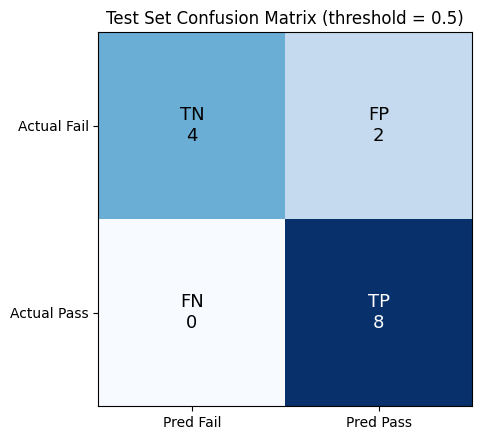

TP=8  TN=4  FP=2  FN=0


In [12]:
def confusion_matrix(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn


def plot_confusion_matrix(y_true, y_pred, title):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    matrix = np.array([[tn, fp], [fn, tp]])
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(matrix, cmap='Blues')
    labels = np.array([['TN', 'FP'], ['FN', 'TP']])
    for (i, j), val in np.ndenumerate(matrix):
        ax.text(j, i, f"{labels[i,j]}\n{val}", ha='center', va='center', fontsize=13,
                color='white' if val > matrix.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Fail', 'Pred Pass'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual Fail', 'Actual Pass'])
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return tp, tn, fp, fn


tp, tn, fp, fn = plot_confusion_matrix(y_test, predict_class(X_test_design, theta, 0.5), "Test Set Confusion Matrix (threshold = 0.5)")
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

## 3. All the metrics, from scratch

In [13]:
def accuracy_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return (tp + tn) / (tp + tn + fp + fn)

def precision_score(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    """AKA True Positive Rate (TPR) / sensitivity."""
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def false_positive_rate(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

def f1_score(y_true, y_pred):
    p, r = precision_score(y_true, y_pred), recall_score(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def evaluate_at_threshold(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall (TPR)': recall_score(y_true, y_pred),
        'FPR': false_positive_rate(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
    }

## 4. Threshold tuning at 0.3, 0.5, 0.7

Raising the threshold makes the model more conservative about predicting
"Pass" — fewer positives overall, so precision tends to rise and recall
tends to fall. Lowering it does the opposite.

In [14]:
thresholds_to_compare = [0.3, 0.5, 0.7]
threshold_rows = [evaluate_at_threshold(y_test, y_scores_test, t) for t in thresholds_to_compare]
threshold_df = pd.DataFrame(threshold_rows).round(4)
threshold_df

,threshold,accuracy,precision,recall (TPR),FPR,F1
0,0.3,0.8571,0.8,1.0,0.3333,0.8889
1,0.5,0.8571,0.8,1.0,0.3333,0.8889
2,0.7,0.8571,0.8,1.0,0.3333,0.8889


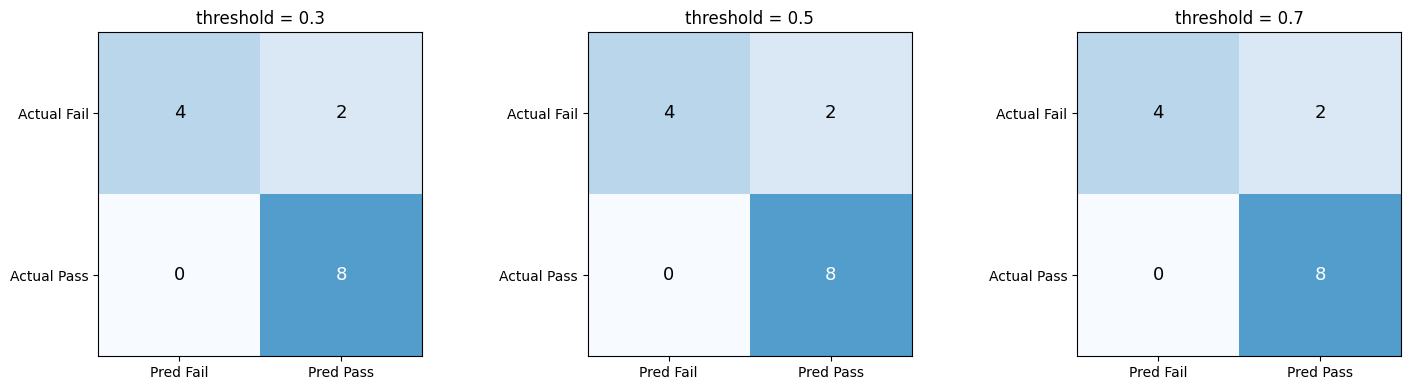

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, thresholds_to_compare):
    y_pred_t = (y_scores_test >= t).astype(int)
    tp, tn, fp, fn = confusion_matrix(y_test, y_pred_t)
    matrix = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=max(y_test.shape[0], 1))
    for (i, j), val in np.ndenumerate(matrix):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=13,
                color='white' if val > matrix.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Fail', 'Pred Pass'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual Fail', 'Actual Pass'])
    ax.set_title(f"threshold = {t}")
plt.tight_layout()
plt.show()

### Reading the threshold sweep

- **threshold = 0.3** - the model predicts "Pass" more readily (a lower
  bar of evidence). Expect **recall to be highest** here: fewer actual
  passers get missed (low FN). The trade-off is more false positives -
  some students who will actually fail get told they're passing.
- **threshold = 0.5** - the default, roughly balanced decision rule.
- **threshold = 0.7** - the model only predicts "Pass" when it's quite
  confident. Expect **precision to be highest**: almost everyone predicted
  to pass really does. The trade-off is more false negatives - some
  actual passers get flagged as at-risk unnecessarily.

(The exact numbers are in the table above — with only 14 test rows the
values can jump between thresholds in visible steps, since each flipped
prediction changes a count by a whole student.)

## 5. Precision-recall trade-off across a full threshold sweep

Rather than just three points, sweep the threshold from 0 to 1 and watch
precision and recall move.

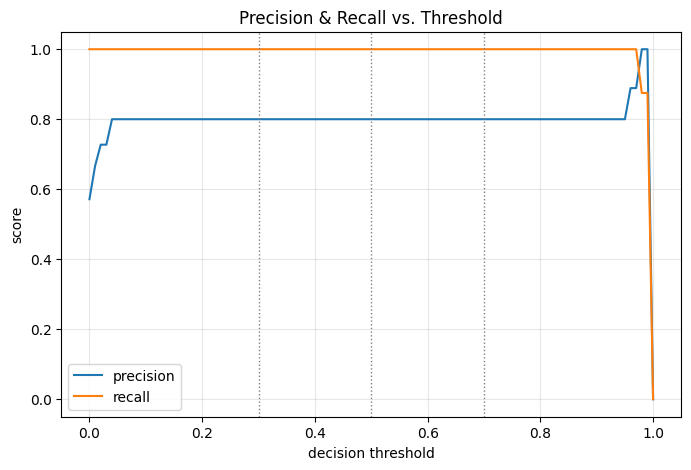

In [16]:
def compute_pr_curve(y_true, y_scores, n_thresholds=101):
    """
    Sweep thresholds from 0 to 1 and compute precision/recall at each.

    Returns thresholds, precisions, recalls (all arrays of equal length).
    """
    thresholds = np.linspace(0, 1, n_thresholds)
    precisions, recalls = [], []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred))
        recalls.append(recall_score(y_true, y_pred))
    return thresholds, np.array(precisions), np.array(recalls)


pr_thresholds, precisions, recalls = compute_pr_curve(y_test, y_scores_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_thresholds, precisions, label='precision')
ax.plot(pr_thresholds, recalls, label='recall')
for t in thresholds_to_compare:
    ax.axvline(t, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('decision threshold')
ax.set_ylabel('score')
ax.set_title('Precision & Recall vs. Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. ROC curve & AUC, from scratch

The ROC curve plots **True Positive Rate** (recall) against **False
Positive Rate** as the threshold sweeps from 1 down to 0. A model that's
no better than random guessing traces the diagonal; a perfect model hugs
the top-left corner. **AUC** (area under this curve) summarizes it in one
number: 0.5 = random, 1.0 = perfect separation of the two classes.

In [17]:
def compute_roc_curve(y_true, y_scores, n_thresholds=101):
    """
    Sweep thresholds from 1 down to 0 and compute (FPR, TPR) at each,
    tracing the ROC curve from (0,0) to (1,1).
    """
    thresholds = np.linspace(1, 0, n_thresholds)
    tpr_list, fpr_list = [], []
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tpr_list.append(recall_score(y_true, y_pred))         # TPR = recall
        fpr_list.append(false_positive_rate(y_true, y_pred))
    return np.array(fpr_list), np.array(tpr_list), thresholds


def trapezoidal_area(x, y):
    """
    Area under a curve defined by points (x, y), via the trapezoidal rule.
    x must be sorted ascending. Implemented directly (no np.trapz, which
    was removed in NumPy 2.x) - sum of (base * average height) per segment.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)


def compute_auc(fpr, tpr):
    """Area under the ROC curve via the trapezoidal rule."""
    order = np.argsort(fpr)
    return trapezoidal_area(fpr[order], tpr[order])


fpr, tpr, roc_thresholds = compute_roc_curve(y_test, y_scores_test)
auc_score = compute_auc(fpr, tpr)
print(f"AUC = {auc_score:.4f}")

AUC = 0.9896


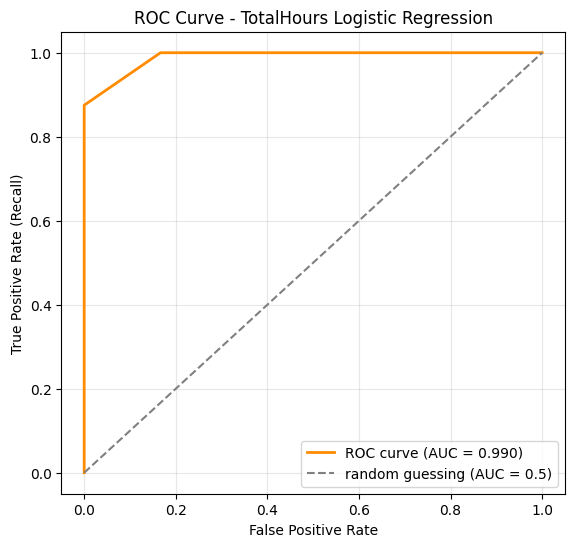

In [18]:
plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='random guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - TotalHours Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Interpreting AUC

AUC has a clean probabilistic meaning: it's the probability that, if you
pick one random Pass student and one random Fail student, the model
assigns a **higher** predicted probability to the actual passer. An AUC
well above 0.5 means `TotalHours` genuinely separates the two classes -
which matches what the fitted sigmoid curve already suggested visually in
the single-feature notebook.

## 7. Precision-Recall curve

Especially useful for imbalanced problems (less of a concern here at the
50-mark cut-off, but still standard practice): plot precision against
recall directly, using the same sweep as Section 5.

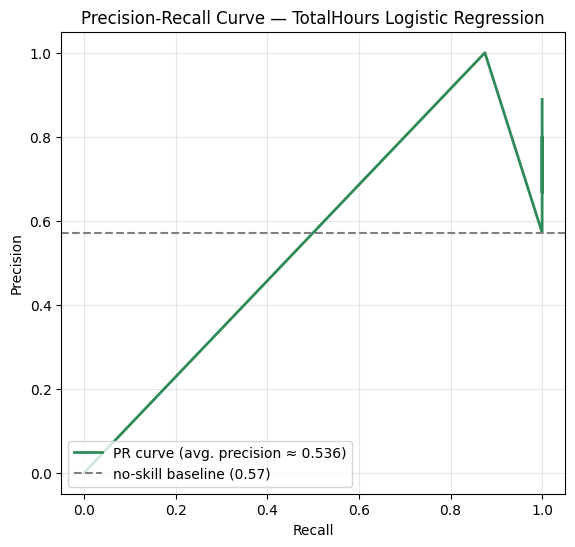

In [19]:
# Sort by recall for a clean left-to-right curve
order = np.argsort(recalls)
recalls_sorted = recalls[order]
precisions_sorted = precisions[order]
avg_precision = trapezoidal_area(recalls_sorted, precisions_sorted)

plt.figure(figsize=(6.5, 6))
plt.plot(recalls_sorted, precisions_sorted, color='seagreen', linewidth=2,
         label=f'PR curve (avg. precision ≈ {avg_precision:.3f})')
baseline = y_test.mean()   # a no-skill classifier's precision = the positive class rate
plt.axhline(baseline, color='gray', linestyle='--', label=f'no-skill baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — TotalHours Logistic Regression')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

## 8. Business impact: which threshold should actually be used?

This is a judgment call about **what the prediction is used for**, not a
purely statistical one. Two plausible use cases for this model, with
opposite implications:

**Use case A - "Who gets extra tutoring support?"** (limited resources,
FP is expensive because it means a struggling student is missed)
- Favor a **lower threshold** (e.g. 0.3), which raises recall: catch as
  many at-risk students as possible, at the cost of also flagging some
  who would have passed anyway (an extra tutoring session for a student
  who didn't strictly need it is a low-cost mistake).

**Use case B - "Who gets an official 'on track' certificate mid-course?"**
(FP is expensive because it means falsely reassuring a student who then
fails)
- Favor a **higher threshold** (e.g. 0.7), which raises precision: only
  tell students they're on track when the model is quite confident,
  accepting that a few genuine passers won't get the reassurance.

**In general:**
- Lower threshold → higher recall, lower precision → fewer missed
  positives, more false alarms.
- Higher threshold → higher precision, lower recall → fewer false
  alarms, more missed positives.
- The "right" choice depends on which mistake - a false alarm or a missed
  case - is more costly in the real deployment context, which is a policy
  decision informed by, but not decided by, the metrics above.

## 9. Takeaways

- A single accuracy number hides *what kind* of mistakes a model makes.
  The confusion matrix, precision, and recall each surface a different
  piece of that picture.
- Threshold choice is a lever, not a fixed setting - sweeping it (Section
  5) shows the full precision/recall trade-off space, and ROC/PR curves
  (Sections 6-7) summarize that trade-off across every possible threshold
  at once, independent of any one choice.
- AUC and average precision give single-number summaries for comparing
  models, but the *deployment* threshold still has to be chosen
  deliberately based on which error costs more in context - that's the
  business-impact judgment in Section 8, not something the metrics alone
  can answer.